# Orientation and phase mapping from simulated 4D-STEM

In a 4D-STEM experiment a converged electron probe is rastered across the
sample and a full nanodiffraction pattern is recorded at every probe
position: two real-space scan axes plus two reciprocal-space detector axes.
The dataset holds far more than an image; each pattern encodes the local
crystal lattice, so from one scan you can synthesize any virtual detector
image and map local orientation, phase and grain structure.

This notebook walks the full chain on this repository's simulated data,
where the ground truth is known exactly at every probe position:

1. simulate (or load) a polycrystalline scan,
2. inspect the raw patterns,
3. form virtual bright-field and dark-field images,
4. map orientation and phase by template matching,
5. map them with the trained CNN,
6. recover the grain structure with unsupervised clustering,
7. score everything against ground truth and look at the dose behaviour.

Everything runs on CPU in a couple of minutes. The physics is kinematical
(single scattering, Gaussian spots, Poisson counting); the scope section of
the README says plainly what that leaves out.

In [1]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt

from orient4d import (
    PHASE_NAMES, PHASES, load_scan, bright_field, annular_dark_field,
    spot_dark_field, build_library, load_model, cluster_grains,
    grain_agreement, orientation_phase_metrics,
)
from orient4d.template import map_scan as template_map_scan
from orient4d.net import map_scan as cnn_map_scan
from orient4d.plots import orientation_rgb, show_pattern
from orient4d.metrics import angular_error_deg
from orient4d.sim import FOLDS

scan = load_scan("../data/sample/scan_32.npz")
h, w = scan.data.shape[:2]
print(f"scan: {h}x{w} probe positions, {scan.det.n_px}x{scan.det.n_px} px patterns")
print(f"grains: {scan.params.n_grains}, dose: {scan.params.dose:g} electrons/pattern")
print(f"phases present: {[PHASE_NAMES[i] for i in np.unique(scan.phase_id)]}")

scan: 32x32 probe positions, 64x64 px patterns
grains: 6, dose: 300 electrons/pattern
phases present: ['hexagonal', 'square']


## 1. The raw data

The committed sample is a 32x32 scan over six Voronoi grains drawn from two
phases: a graphene-like honeycomb (6-fold symmetric pattern, first ring at
0.47 per angstrom) and an aluminium-like square net (4-fold, first ring at
0.49 per angstrom). The first-ring radii nearly coincide on purpose: the
phases must be told apart by spot geometry, not by a trivial camera-length
cue. Dose is 300 electrons per pattern in total, a quarter of which sits in
the direct beam and 15 percent in a smooth background, so the Bragg spots
carry only a couple of hundred electrons between them.

Below: one interior pattern from each phase and one grain-boundary pattern,
where the probe straddles two grains and records both lattices at once. The
`purity` channel of the ground truth quantifies exactly that mixing.

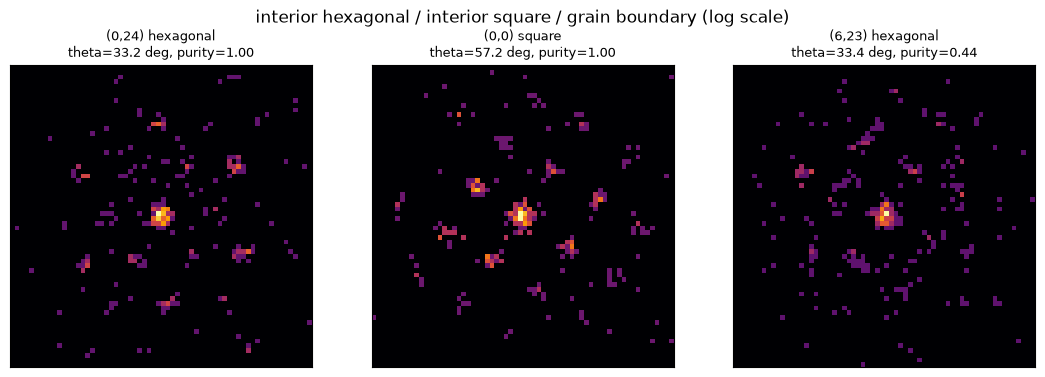

In [2]:
interior = np.argwhere(scan.purity > 0.99)
boundary_idx = np.unravel_index(np.argmin(scan.purity), scan.purity.shape)
picks = []
for pid in (0, 1):
    for i, j in interior:
        if scan.phase_id[i, j] == pid:
            picks.append((int(i), int(j)))
            break
picks.append((int(boundary_idx[0]), int(boundary_idx[1])))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, (i, j) in zip(axes, picks):
    name = PHASE_NAMES[scan.phase_id[i, j]]
    show_pattern(ax, scan.data[i, j], scan.det,
                 title=f"({i},{j}) {name}\ntheta={scan.theta[i, j]:.1f} deg, "
                       f"purity={scan.purity[i, j]:.2f}")
fig.suptitle("interior hexagonal / interior square / grain boundary (log scale)")
fig.tight_layout()
plt.show()

## 2. Virtual imaging

Summing each pattern over a detector-plane mask turns the 4D dataset into
any 2D image after the fact. One honest caveat of this simulator: the
per-pattern intensity budget is fixed (every pattern carries the same dose
and the same direct/scattered/background split regardless of phase), so the
integrated bright-field and annular dark-field images are featureless noise
by construction. Real BF/ADF grain contrast comes from thickness and
channelling effects that this kinematical model does not include.

What does carry grain contrast here, exactly as on a real instrument, is
the spot dark field: a small aperture on one Bragg position lights up only
the grains oriented to diffract into that exact spot. Virtual images locate
grains; mapping their orientation needs the per-pattern analysis of the
next sections.

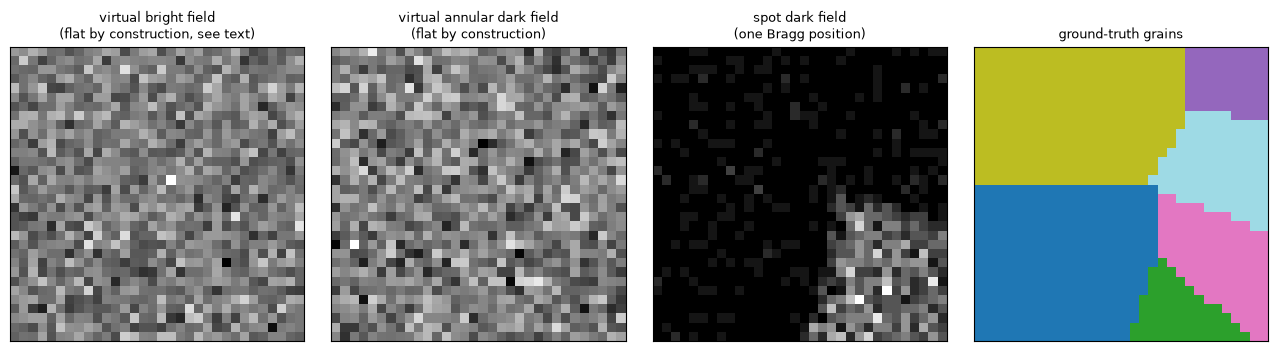

In [3]:
from orient4d.sim import lattice_reflections

g, _ = lattice_reflections(PHASES["hexagonal"], scan.det.k_max)
g0 = g[np.argmin(np.linalg.norm(g, axis=1))]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
images = [
    (bright_field(scan.data, scan.det),
     "virtual bright field\n(flat by construction, see text)"),
    (annular_dark_field(scan.data, scan.det),
     "virtual annular dark field\n(flat by construction)"),
    (spot_dark_field(scan.data, scan.det, (float(g0[1]), float(g0[0]))),
     "spot dark field\n(one Bragg position)"),
]
for ax, (img, name) in zip(axes, images):
    ax.imshow(img, cmap="gray")
    ax.set_title(name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
axes[3].imshow(scan.grain_id, cmap="tab20", interpolation="nearest")
axes[3].set_title("ground-truth grains", fontsize=9)
axes[3].set_xticks([]); axes[3].set_yticks([])
fig.tight_layout()
plt.show()

## 3. Template matching

The classical workhorse. We simulate a noise-free pattern library on a
0.5-degree orientation grid for each phase (120 hexagonal + 180 square
templates over their symmetry-reduced ranges), and score each measured
pattern by normalised cross-correlation on square-root intensities. The best
template assigns phase and orientation; a three-point parabolic fit over the
neighbouring library angles then refines the angle below the grid step.

Because the library is generated by the same forward model that generated
the data, this is close to a matched filter, a deliberately strong baseline.

300 templates, 0.12 ms/pattern
interior phase accuracy:  1.000
interior orientation MAE: 0.254 deg


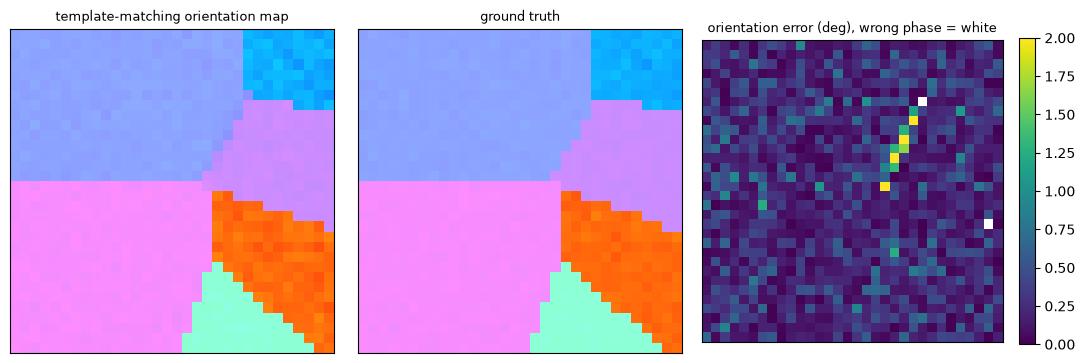

In [4]:
lib = build_library(scan.det, step_deg=0.5)
phase_t, theta_t, res_t = template_map_scan(scan.data, lib)
m_t = orientation_phase_metrics(theta_t, phase_t, scan.theta, scan.phase_id,
                                mask=scan.purity >= 0.95)
print(f"{lib.n_templates} templates, {res_t.seconds_per_pattern*1e3:.2f} ms/pattern")
print(f"interior phase accuracy:  {m_t['phase_accuracy']:.3f}")
print(f"interior orientation MAE: {m_t['orientation_mae_deg']:.3f} deg")

def map_panel(theta_map, phase_map, title):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
    axes[0].imshow(orientation_rgb(theta_map, phase_map))
    axes[0].set_title(title, fontsize=9)
    axes[1].imshow(orientation_rgb(scan.theta, scan.phase_id))
    axes[1].set_title("ground truth", fontsize=9)
    err = angular_error_deg(theta_map, scan.theta, FOLDS[scan.phase_id.astype(int)])
    err = np.where(phase_map == scan.phase_id, err, np.nan)
    im = axes[2].imshow(err, cmap="viridis", vmin=0, vmax=2)
    axes[2].set_title("orientation error (deg), wrong phase = white", fontsize=9)
    fig.colorbar(im, ax=axes[2], fraction=0.046)
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    plt.show()

map_panel(theta_t, phase_t, "template-matching orientation map")

Hue encodes orientation within each phase's symmetry fold (60 degrees for
the hexagonal phase, 90 for the square); the square phase is desaturated so
phase and orientation read from one map. The residual errors concentrate on
grain boundaries, where the pattern genuinely contains two lattices and the
dominant-grain ground truth is only partially right, which is why the
benchmark reports interior (purity >= 0.95) and all-pixel numbers
separately.

## 4. CNN mapping

The learned alternative: a small convolutional network (157k parameters)
maps one pattern directly to phase logits and an orientation estimate. The
orientation head predicts a point on the unit circle of the symmetry-
multiplied angle, cos and sin of n times theta, so the 0/60-degree wrap of a
6-fold pattern is continuous in the loss instead of a discontinuity. It was
trained purely on freshly simulated patterns with full domain randomisation
(dose 10-3000, camera-length and descan jitter, randomised beam and
background budgets, and two-grain boundary mixtures labelled with their
dominant grain).

interior phase accuracy:  1.000
interior orientation MAE: 0.530 deg


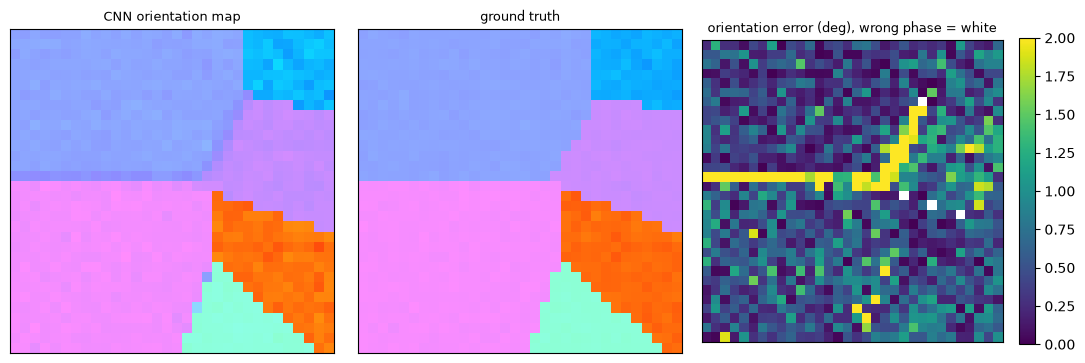

In [5]:
model = load_model("../models/orientnet.pt")
phase_c, theta_c = cnn_map_scan(model, scan.data)
m_c = orientation_phase_metrics(theta_c, phase_c, scan.theta, scan.phase_id,
                                mask=scan.purity >= 0.95)
print(f"interior phase accuracy:  {m_c['phase_accuracy']:.3f}")
print(f"interior orientation MAE: {m_c['orientation_mae_deg']:.3f} deg")
map_panel(theta_c, phase_c, "CNN orientation map")

## 5. Unsupervised grain discovery

No labels, no forward model: sqrt-normalised patterns are reduced with PCA
and clustered with k-means. Positions in the same grain share a lattice and
orientation, so their patterns are nearly identical up to Poisson noise, and
the clusters recover the grain map. The adjusted Rand index scores the
recovery; two grains whose orientations happen to fall within the noise
floor of each other are physically indistinguishable and will merge, which
ARI reports honestly.

ARI 0.992, NMI 0.981 at k = true grain count


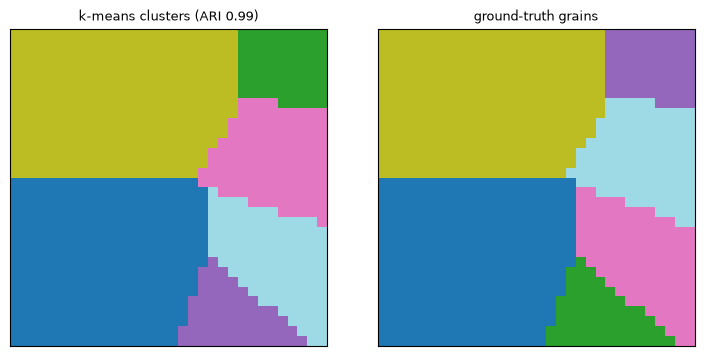

In [6]:
res = cluster_grains(scan.data, k=int(scan.params.n_grains), seed=0)
agree = grain_agreement(res.labels, scan.grain_id)
print(f"ARI {agree['ari']:.3f}, NMI {agree['nmi']:.3f} at k = true grain count")

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))
axes[0].imshow(res.labels, cmap="tab20", interpolation="nearest")
axes[0].set_title(f"k-means clusters (ARI {agree['ari']:.2f})", fontsize=9)
axes[1].imshow(scan.grain_id, cmap="tab20", interpolation="nearest")
axes[1].set_title("ground-truth grains", fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## 6. Dose behaviour and the final score

The committed benchmarks sweep dose, grain count, mosaic spread, pattern
resolution and the template-library step with fixed seeds
(`configs/*.yaml`); here we just plot the committed dose-sweep results and
close with this notebook's own measured numbers.

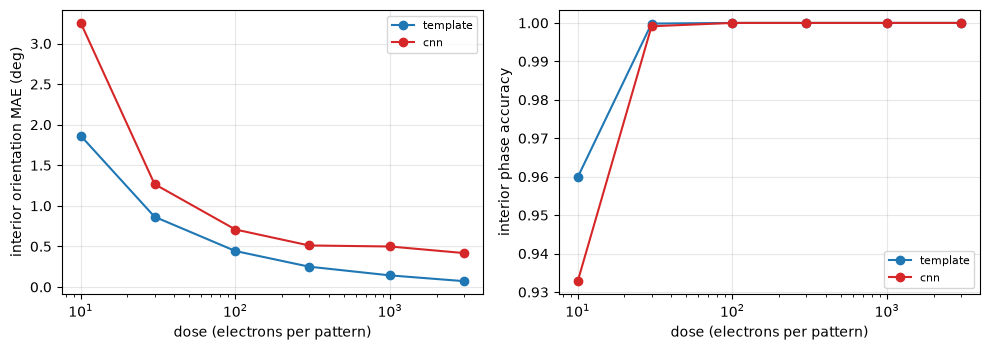

In [7]:
with open("../results/dose_sweep.json", encoding="utf-8") as fh:
    sweep = json.load(fh)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for method, color in [("template", "#1f77b4"), ("cnn", "#d62728")]:
    doses, mae, acc = [], [], []
    for cond in sweep["conditions"]:
        agg = cond["methods"][method]["aggregate"]
        doses.append(cond["value"])
        mae.append(agg["interior_orientation_mae_deg"]["mean"])
        acc.append(agg["interior_phase_accuracy"]["mean"])
    axes[0].plot(doses, mae, "o-", color=color, label=method)
    axes[1].plot(doses, acc, "o-", color=color, label=method)
axes[0].set_ylabel("interior orientation MAE (deg)")
axes[1].set_ylabel("interior phase accuracy")
for ax in axes:
    ax.set_xlabel("dose (electrons per pattern)")
    ax.set_xscale("log")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [8]:
print("final scores on the committed sample scan (grain-interior pixels):")
print(f"{'method':<20} {'phase acc':>10} {'orient MAE (deg)':>18}")
for name, m in [("template matching", m_t), ("CNN", m_c)]:
    print(f"{name:<20} {m['phase_accuracy']:>10.3f} {m['orientation_mae_deg']:>18.3f}")
print(f"{'clustering (ARI)':<20} {agree['ari']:>10.3f}")

final scores on the committed sample scan (grain-interior pixels):
method                phase acc   orient MAE (deg)
template matching         1.000              0.254
CNN                       1.000              0.530
clustering (ARI)          0.992


## Takeaways

- On in-model data, template matching with sub-step refinement beats the
  CNN at every dose measured here, and even a 30-template library with
  parabolic refinement outperforms it. When the classical method is a true
  matched filter built from the exact forward model, deep learning has
  nothing to add; RESULTS.md quantifies this plainly, along with the one
  condition where the gap nearly closes (forward-model mismatch between the
  library and the data).
- Virtual spot dark fields locate grains cheaply; per-pattern analysis is
  what adds orientation and phase.
- Boundary pixels are genuinely mixed states. Score maps with that in mind,
  and read the purity channel before trusting a single-grain label there.